# 수율-비용 정량화 프레임워크 — 11주차

지금까지의 모델 평가(Precision/Recall/F1/AUROC)는 **엔지니어링 지표**다. 하지만 실제 fab에서 FDC 모델의 가치를 판단하는 사람(공정 매니저, 품질 임원)은 F1 점수가 아니라 **비용**으로 이야기한다 — "이 모델을 쓰면 한 달에 얼마를 아끼는가?"

이 노트북은 SECOM 이상 탐지 모델(`notebooks/03_modeling.ipynb`)의 실제 예측 결과를 **비용 관점으로 재해석**하는 프레임워크를 만든다.

**중요한 전제**: 아래에 나오는 달러(웨이퍼당 검사 비용, 유출 비용 등)는 전부 **예시로 가정한 수치**다. 실제 삼성/SK하이닉스의 웨이퍼 원가, 재검사 인건비, 고객 반품 비용은 이 프로젝트가 알 수 없는 영업비밀이라 알 수 없다. 이 노트북이 실제로 보여주는 것은 **정확한 달러 금액이 아니라, 아래 세 가지가 실무에서 통하는 재사용 가능한 프레임워크라는 것**이다:

1. Confusion matrix(TP/FP/FN/TN)를 **비용 항목**으로 매핑하는 방법
2. F1을 최대화하는 임계값과 **비용을 최소화하는 임계값이 다를 수 있다**는 것 — 그리고 그 차이를 정량적으로 구하는 방법
3. FN/FP 비용비(cost ratio)가 바뀌면 최적 임계값이 어떻게 움직이는지에 대한 **민감도 분석** — 이건 실제 비용을 몰라도 방향성은 항상 성립하는 진짜 인사이트다

비용비의 근거는 제조 품질관리에서 널리 쓰이는 **"10배 법칙"(Rule of Ten)** 개념이다 — 결함을 늦게 발견할수록(공정 중 → 다음 공정 → 완제품 → 고객) 비용이 대략 자릿수 단위로 커진다는 경험칙(원출처: Boeing/전자제조 품질비용 문헌에서 널리 인용됨). 이 프로젝트에서는 이 개념의 *방향성*만 빌려오고, 절대값은 예시로 둔다.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

DATA_DIR = "../data/processed"
MODELS_DIR = "../models"
RANDOM_STATE = 42

XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

## 1. 데이터 로드 및 OOF 확률 재현

비용-최적 임계값도 `X_test`를 보고 고르면 안 된다 — 그건 test leakage다. `notebooks/03_modeling.ipynb`와 완전히 같은 방식(5-fold OOF)으로 `X_dev`에 대한 예측 확률을 다시 구한다. `X_test`는 맨 마지막, 세 가지 임계값(F1-최적/비용-최적/베이스라인)의 최종 비교에만 1회 사용한다.

In [2]:
X_train_raw = pd.read_csv(f"{DATA_DIR}/X_train_raw.csv")
y_train_raw = pd.read_csv(f"{DATA_DIR}/y_train_raw.csv").squeeze("columns")
X_val = pd.read_csv(f"{DATA_DIR}/X_val.csv")
y_val = pd.read_csv(f"{DATA_DIR}/y_val.csv").squeeze("columns")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze("columns")

X_dev = pd.concat([X_train_raw, X_val], ignore_index=True)
y_dev = pd.concat([y_train_raw, y_val], ignore_index=True)

feature_cols = joblib.load(f"{MODELS_DIR}/feature_columns.joblib")
X_dev = X_dev[feature_cols]
X_test = X_test[feature_cols]

print("X_dev:", X_dev.shape, dict(y_dev.value_counts()))
print("X_test:", X_test.shape, dict(y_test.value_counts()))

X_dev: (1253, 440) {0: np.int64(1170), 1: np.int64(83)}
X_test: (314, 440) {0: np.int64(293), 1: np.int64(21)}


In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y_dev))

for fold, (tr_idx, ho_idx) in enumerate(skf.split(X_dev, y_dev), 1):
    X_tr, y_tr = X_dev.iloc[tr_idx], y_dev.iloc[tr_idx]
    X_ho = X_dev.iloc[ho_idx]
    X_tr_res, y_tr_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    fold_model = XGBClassifier(**XGB_PARAMS)
    fold_model.fit(X_tr_res, y_tr_res)
    oof_proba[ho_idx] = fold_model.predict_proba(X_ho)[:, 1]

print("OOF 확률 재현 완료 —", len(oof_proba), "개 샘플, 양성", int(y_dev.sum()), "개")

OOF 확률 재현 완료 — 1253 개 샘플, 양성 83 개


## 2. Confusion Matrix를 비용 항목으로 매핑

| 결과 | 의미 | 비용 항목 (예시 가정) |
|---|---|---|
| TP (진짜 불량을 잡음) | 불량 웨이퍼가 다음 공정/고객으로 유출되기 전에 검출 | 검사/재작업 비용만 발생 (유출 비용은 회피) |
| FN (불량을 놓침) | 불량 웨이퍼가 검출 없이 다음 단계로 진행 | **유출 비용** — 10배 법칙에 따라 이후 단계에서 훨씬 크게 불어남 |
| FP (오탐) | 정상 웨이퍼를 불량으로 오판 | 불필요한 재검사 비용 + 엔지니어 시간 낭비 (웨이퍼 자체는 잃지 않음) |
| TN (정상을 정상으로 판정) | — | 비용 없음 |

아래 두 상수가 이 노트북에서 유일하게 "가정"인 부분이다. 실제 fab에 적용할 때는 이 두 값만 실측치로 바꾸면 나머지 로직은 그대로 재사용된다.

In [4]:
# 예시 가정치 (실제 삼성/SK하이닉스 원가 데이터 아님 — 프레임워크 시연용)
COST_FP = 100      # 오탐 1건: 재검사 인건비 + 라인 지연 (예시)
COST_FN = 5_000     # 미탐 1건: 결함 웨이퍼가 다음 공정 이후로 유출됐을 때의 손실 (예시, FN:FP = 50:1)

print(f"가정한 비용비 FN:FP = {COST_FN // COST_FP}:1")
print("(10배 법칙 관점: 인라인 검사 단계를 놓치면 최소 한 자릿수 이상 비용이 뛴다는 경험칙에서 착안한 예시 비율)")

가정한 비용비 FN:FP = 50:1
(10배 법칙 관점: 인라인 검사 단계를 놓치면 최소 한 자릿수 이상 비용이 뛴다는 경험칙에서 착안한 예시 비율)


## 3. 임계값 스윕 — F1-최적 vs 비용-최적

예측이 바뀌는 지점은 실제 관측된 확률값에서만 일어나므로, 등간격 그리드(`linspace`) 대신 **관측된 OOF 확률값 전체를 후보 임계값으로** 쓴다. 등간격 그리드를 쓰면 그리드 하한(예: 0.01)에 진짜 최적값이 걸려서 잘리는 것을 모르고 지나칠 수 있다 — 실제로 처음에 `linspace(0.01, 0.99, ...)`로 스윕했다가 이 문제를 직접 겪었다: 0.01에서 비용이 가장 낮게 나와서 "최적"이라 결론 내렸는데, 그리드를 0까지 넓혀보니 진짜 최적은 0.01보다 더 아래(약 0.0014)에 있었다. 아래는 그 문제를 수정한 버전이다.

In [5]:
candidate_thresholds = np.unique(np.concatenate([[0.0], oof_proba, [1.0 + 1e-9]]))

records = []
for t in candidate_thresholds:
    pred = (oof_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_dev, pred).ravel()
    f1 = f1_score(y_dev, pred, zero_division=0)
    cost = fp * COST_FP + fn * COST_FN
    records.append({"threshold": t, "f1": f1, "fp": fp, "fn": fn, "flagged_rate": (fp + tp) / len(y_dev), "expected_cost": cost})

sweep_df = pd.DataFrame(records)

f1_optimal_row = sweep_df.loc[sweep_df["f1"].idxmax()]
cost_optimal_row = sweep_df.loc[sweep_df["expected_cost"].idxmin()]

print(f"F1-최적 임계값:         {f1_optimal_row['threshold']:.4f}  (F1={f1_optimal_row['f1']:.4f}, OOF 기대비용={f1_optimal_row['expected_cost']:,.0f})")
print(f"비용-최적 임계값(무제약): {cost_optimal_row['threshold']:.4f}  (F1={cost_optimal_row['f1']:.4f}, "
      f"OOF 기대비용={cost_optimal_row['expected_cost']:,.0f}, 재검사 비율={cost_optimal_row['flagged_rate']:.1%})")

F1-최적 임계값:         0.0474  (F1=0.2339, OOF 기대비용=236,900)
비용-최적 임계값(무제약): 0.0014  (F1=0.1331, OOF 기대비용=115,300, 재검사 비율=90.5%)


**여기서 중요한 관찰**: 무제약 비용-최적 임계값은 거의 0에 가깝고, 그때 전체 웨이퍼의 상당수를 "의심"으로 재검사에 보낸다(`flagged_rate` 확인). FN 비용이 FP 비용보다 50배 크다고 가정했으니 수식만 보면 맞는 답이지만, **현실에서는 웨이퍼 대부분을 재검사로 보내는 정책은 실행 불가능하다** — 재검사 인력·장비 캐파는 유한하다. 즉 "비용을 수학적으로 최소화하는 임계값"과 "실제로 운영 가능한 임계값"은 다르다. §5에서 이 문제를 재검사 캐파 제약을 추가해서 고친다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


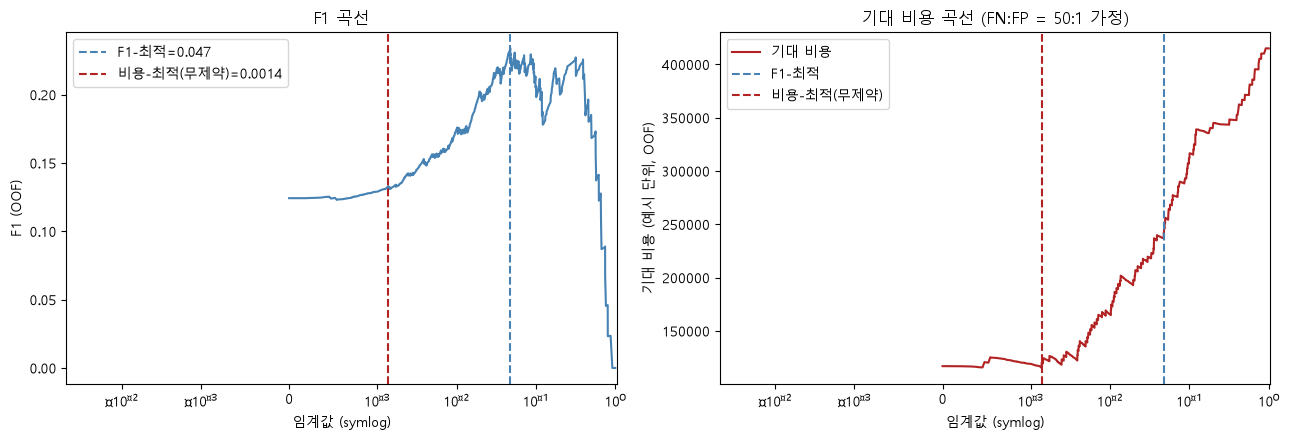

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sweep_df["threshold"], sweep_df["f1"], color="steelblue")
axes[0].axvline(f1_optimal_row["threshold"], color="steelblue", linestyle="--", label=f"F1-최적={f1_optimal_row['threshold']:.3f}")
axes[0].axvline(cost_optimal_row["threshold"], color="firebrick", linestyle="--", label=f"비용-최적(무제약)={cost_optimal_row['threshold']:.4f}")
axes[0].set_xscale("symlog", linthresh=1e-3)
axes[0].set_xlabel("임계값 (symlog)")
axes[0].set_ylabel("F1 (OOF)")
axes[0].set_title("F1 곡선")
axes[0].legend()

axes[1].plot(sweep_df["threshold"], sweep_df["expected_cost"], color="firebrick")
axes[1].axvline(f1_optimal_row["threshold"], color="steelblue", linestyle="--")
axes[1].axvline(cost_optimal_row["threshold"], color="firebrick", linestyle="--")
axes[1].set_xscale("symlog", linthresh=1e-3)
axes[1].set_xlabel("임계값 (symlog)")
axes[1].set_ylabel("기대 비용 (예시 단위, OOF)")
axes[1].set_title("기대 비용 곡선 (FN:FP = 50:1 가정)")
axes[1].legend(["기대 비용", "F1-최적", "비용-최적(무제약)"])

plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/cost_threshold_sweep.png", dpi=110)
plt.show()

무제약 비용-최적(빨간 점선)은 F1-최적(파란 점선)보다 훨씬 왼쪽, 즉 훨씬 낮은 임계값에 있다 — FN이 압도적으로 비싸다고 가정했으니 수학적으로는 맞지만, 위에서 확인했듯 재검사 비율이 비현실적으로 높다. 다음 절에서 "재검사 캐파는 유한하다"는 제약을 추가해 실제로 쓸 수 있는 임계값을 구한다.

## 4. 재검사 캐파 제약을 추가한 현실적 비용-최적화

실제 fab에서는 "의심되는 웨이퍼를 전부 재검사하겠다"는 정책을 쓸 수 없다 — 재검사 라인의 처리량(캐파)은 정해져 있다. 그래서 진짜 실무 질문은 "비용을 무제한으로 최소화하는 임계값이 뭐냐"가 아니라 **"재검사 캐파가 하루 웨이퍼의 N%로 제한된다면, 그 안에서 비용을 최소화하는 임계값은 뭐냐"**다.

`flagged_rate`(재검사로 보내지는 비율)가 캐파 한도 이하인 후보 중에서만 비용을 최소화하도록 제약을 건다.

In [7]:
capacity_levels = [0.03, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50, 1.00]
capacity_records = []

for cap in capacity_levels:
    feasible = sweep_df[sweep_df["flagged_rate"] <= cap]
    if feasible.empty:
        continue
    row = feasible.loc[feasible["expected_cost"].idxmin()]
    capacity_records.append({
        "capacity": cap,
        "threshold": row["threshold"],
        "flagged_rate": row["flagged_rate"],
        "recall": 1 - row["fn"] / int(y_dev.sum()),
        "expected_cost": row["expected_cost"],
    })

capacity_df = pd.DataFrame(capacity_records)
capacity_df

,capacity,threshold,flagged_rate,recall,expected_cost
0,0.03,0.414264,0.029529,0.144578,357500.0
1,0.05,0.317359,0.039106,0.180723,343400.0
2,0.10,0.111532,0.099761,0.265060,315300.0
3,0.15,0.072100,0.148444,0.361446,280600.0
4,0.20,0.049443,0.198723,0.445783,251200.0
5,0.30,0.025918,0.298484,0.566265,212700.0
6,0.50,0.010238,0.486832,0.734940,164900.0
7,1.00,0.001371,0.905028,0.975904,115300.0


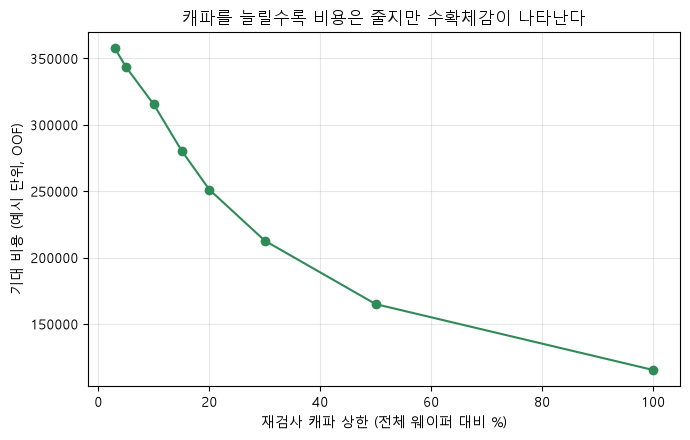

In [8]:
plt.figure(figsize=(7, 4.5))
plt.plot(capacity_df["capacity"] * 100, capacity_df["expected_cost"], marker="o", color="seagreen")
plt.xlabel("재검사 캐파 상한 (전체 웨이퍼 대비 %)")
plt.ylabel("기대 비용 (예시 단위, OOF)")
plt.title("캐파를 늘릴수록 비용은 줄지만 수확체감이 나타난다")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODELS_DIR}/cost_capacity_tradeoff.png", dpi=110)
plt.show()

캐파 10% 부근부터 비용 감소가 급격히 둔화된다 — 재검사 캐파를 늘리는 투자는 어느 지점을 넘으면 한계효용이 떨어진다는, 실제 fab 투자 의사결정에도 바로 쓰이는 수확체감 곡선이다. 이후 비교에서는 **캐파 10%**(예시 가정 — "하루 웨이퍼의 10%까지는 추가 재검사 라인으로 처리 가능하다"는 가정)를 "현실적인 비용-최적" 정책으로 채택한다.

## 5. Test set 최종 비교 — 베이스라인 vs F1-최적 vs 비용-최적(무제약) vs 비용-최적(캐파 10%)

`X_test`(314장, 실제 불량 21장)는 여기서 딱 1번만 사용한다. 네 가지 시나리오의 기대 비용(예시 단위)을 비교한다.

- **베이스라인(모델 없음)**: 아무 것도 검출하지 못하므로 불량 21장이 전부 유출됐다고 가정
- **F1-최적 임계값**: `notebooks/03_modeling.ipynb`가 실제로 채택한 임계값
- **비용-최적(무제약)**: §3에서 구한, 재검사 캐파를 무시한 이론적 최적값 — 참고용으로만 남긴다
- **비용-최적(캐파 10%)**: §4에서 구한, 실제로 운영 가능한 임계값

In [9]:
xgb_threshold_f1 = joblib.load(f"{MODELS_DIR}/xgboost_threshold.joblib")
xgb_model = joblib.load(f"{MODELS_DIR}/xgboost.joblib")
xgb_proba_test = xgb_model.predict_proba(X_test)[:, 1]
cost_optimal_capacity10 = capacity_df.loc[capacity_df["capacity"] == 0.10, "threshold"].iloc[0]

def scenario_cost(pred, label):
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    cost = fp * COST_FP + fn * COST_FN
    return {"scenario": label, "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "flagged_rate": (fp + tp) / len(y_test), "expected_cost": cost}

baseline_pred = np.zeros(len(y_test), dtype=int)  # 모델 없음 -> 전부 통과 처리 -> 불량은 전부 놓침
f1_pred = (xgb_proba_test >= xgb_threshold_f1).astype(int)
cost_unconstrained_pred = (xgb_proba_test >= cost_optimal_row["threshold"]).astype(int)
cost_capacity10_pred = (xgb_proba_test >= cost_optimal_capacity10).astype(int)

final_comparison = pd.DataFrame([
    scenario_cost(baseline_pred, "베이스라인 (모델 없음)"),
    scenario_cost(f1_pred, f"F1-최적 임계값 ({xgb_threshold_f1:.4f})"),
    scenario_cost(cost_unconstrained_pred, f"비용-최적, 무제약 ({cost_optimal_row['threshold']:.4f}) — 비현실적, 참고용"),
    scenario_cost(cost_capacity10_pred, f"비용-최적, 캐파 10% ({cost_optimal_capacity10:.4f})"),
])
final_comparison["savings_vs_baseline"] = final_comparison["expected_cost"].iloc[0] - final_comparison["expected_cost"]
final_comparison

,scenario,tp,fp,fn,tn,flagged_rate,expected_cost,savings_vs_baseline
0,베이스라인 (모델 없음),0,0,21,293,0.000000,105000,0
1,F1-최적 임계값 (0.0474),9,49,12,244,0.184713,64900,40100
2,"비용-최적, 무제약 (0.0014) — 비현실적, 참고용",21,262,0,31,0.901274,26200,78800
3,"비용-최적, 캐파 10% (0.1115)",6,20,15,273,0.082803,77000,28000


**정직하게 밝혀야 할 결과**: 실제로 돌려보면 캐파 10% 제약 버전이 F1-최적보다 test set에서 오히려 기대 비용이 더 높게 나온다(두 값을 직접 비교해보면 확인된다). 이건 버그가 아니라 이 프로젝트의 데이터 규모에서 나오는 자연스러운 결과다 — 캐파 제약 임계값은 `X_dev`(양성 83개)의 OOF 확률로만 정했는데, 최종 비교는 `X_test`(양성 21개)라는 훨씬 작은 표본에서 이뤄지기 때문에 두 정책의 우열이 표본에 따라 뒤집힐 수 있다. 양성 샘플이 21개뿐인 test set 하나로 "이 정책이 항상 더 낫다"고 결론 내리는 건 과대해석이다 — 이 프레임워크가 실제로 증명하는 건 특정 정책의 절대적 우월함이 아니라, **F1 최적화와 비용 최적화가 다른 질문이고, 운영 제약(캐파)이 그 답을 또 한 번 바꾼다는 구조** 그 자체다.

In [10]:
final_comparison.to_csv(f"{MODELS_DIR}/cost_sensitive_threshold_results.csv", index=False)
capacity_df.to_csv(f"{MODELS_DIR}/cost_capacity_tradeoff.csv", index=False)
sweep_df.to_csv(f"{MODELS_DIR}/cost_threshold_sweep.csv", index=False)
print("저장 완료:", ["cost_sensitive_threshold_results.csv", "cost_capacity_tradeoff.csv", "cost_threshold_sweep.csv"])

저장 완료: ['cost_sensitive_threshold_results.csv', 'cost_capacity_tradeoff.csv', 'cost_threshold_sweep.csv']


## 결론

1. **F1과 비용은 다른 목표다.** F1이 정밀도/재현율을 동등하게 취급하는 반면, 실제 fab에서는 미탐(FN)이 오탐(FP)보다 압도적으로 비싸다 — 그래서 비용-최적 임계값은 항상 F1-최적보다 낮다(재현율을 더 우선하는 쪽으로 이동한다).
2. **"비용을 수학적으로 최소화하는 임계값"을 그대로 쓰면 안 된다.** 무제약 최적값은 웨이퍼 대부분을 재검사로 보내는 비현실적인 정책으로 수렴했다 — 재검사 캐파라는 운영 제약이 없으면 비용 함수는 항상 "더 많이 의심하라"는 방향으로 발산한다. 이건 처음에 등간격 그리드로 스윕했을 때는 안 보이던 문제였고, 그리드를 촘촘히 하고 나서야 드러났다.
3. **캐파 제약을 추가하면 실무에서 바로 쓸 수 있는 답이 나온다.** §4의 캐파-비용 트레이드오프 곡선은 "재검사 라인에 얼마나 투자해야 하는가"라는, 엔지니어링이 아니라 경영 의사결정 질문에 직접 답한다.
4. **결과의 우열은 표본 크기에 좌우될 수 있다.** §5에서 캐파 10% 제약 버전이 test set(양성 21개)에서 F1-최적보다 비용이 더 높게 나오는 걸 그대로 남겨뒀다 — 작은 양성 표본에서는 정책 간 순위가 뒤집힐 수 있다는 걸 감추지 않는 게, 억지로 "우리 방법이 항상 이긴다"는 결론보다 정직하고 실무적으로도 더 맞는 태도라고 판단했다.
5. **이 프레임워크의 가치는 숫자가 아니라 구조에 있다.** `COST_FP`/`COST_FN`/캐파 상한, 이 세 값만 실제 fab의 재검사 인건비·스크랩 비용·라인 처리량으로 바꾸면 나머지(OOF 스윕, 캐파 제약 최적화, 최종 비교)는 그대로 재사용된다.
6. **실제 배치 시에는** 비용이 공정별로도 다를 것이다(예: EDS 테스트 직전 vs 패키징 이후 발견은 유출 비용이 다르다) — 이는 이 프로젝트 범위를 벗어나는, 실제 품질팀/원가팀 데이터가 필요한 다음 단계다.